# 08 · Soil Dielectric Mixing Models (Behari 2005, Chapter 6)

Simulates and compares all major dielectric mixing models for wet soil
from Chapter 6 of Behari (2005):

- **Wang & Schmugge (1980)** — two-region empirical model (Eq. 6.1–6.5)
- **Dobson et al. (1985)** — semi-empirical 4-component model (Eq. 6.6–6.10)
- **Rayleigh mixing** — spherical inclusions (Eq. 6.24)
- **Bottcher / Polder-van Santen** — implicit formula (Eq. 6.33–6.34)
- **Refractive mixing** — square-root formula (Eq. 6.12–6.13)
- **4-component mixing** — Sahu/Behari model (Eq. 6.39)
- **Hallikainen (1985)** — empirical polynomial (for comparison)

Reproduces **Fig. 6.2** and **Fig. 6.3** style comparisons.

---
**Reference**
- Behari, J. (2005). *Microwave Dielectric Behavior of Wet Soils*. Springer.
  ISBN 1-4020-3271-4. Chapter 6.
- Hallikainen, M. T., et al. (1985). IEEE TGRS, GE-23(1), 25–34.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from navasar.behari import (
    wang_schmugge, dobson_semiemp, rayleigh_mixing,
    bottcher_mixing, refractive_mixing, four_component_mixing,
    cole_cole_water, emissivity_smooth, penetration_depth
)
from navasar.dielectric import hallikainen_dielectric

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

mv = np.linspace(0.01, 0.50, 150)
SAND, CLAY = 51.5, 13.5   # sandy loam (Behari Table 5.6, soil 1)

## Fig. 6.2 style — All mixing models vs moisture at L-band

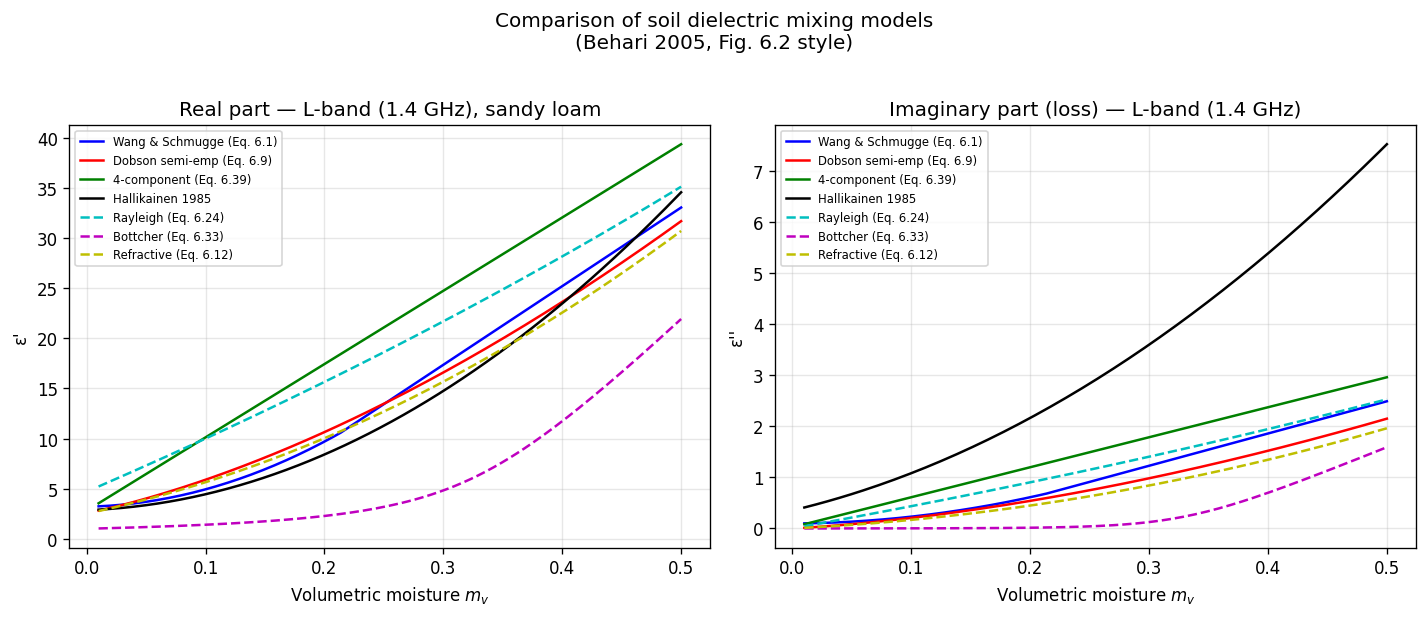

In [2]:
# Compute all models
eps_ws  = wang_schmugge(mv, freq_ghz=1.4, sand_pct=SAND, clay_pct=CLAY)
eps_db  = dobson_semiemp(mv, freq_ghz=1.4, sand_pct=SAND, clay_pct=CLAY)
eps_4c  = four_component_mixing(mv, freq_ghz=1.4, sand_pct=SAND, clay_pct=CLAY)
eps_hal = hallikainen_dielectric(mv, freq_ghz=1.4, sand=SAND/100, clay=CLAY/100)

# Rayleigh: soil solids (eps~5) in water background — simplified
eps_fw = cole_cole_water(1.4, 20)
eps_ray = rayleigh_mixing(eps_fw, 4.7+0j, 1 - mv)   # soil fraction = 1-mv

# Bottcher
eps_bot = bottcher_mixing(1.0+0j, eps_fw, mv)   # water in air background

# Refractive: 3-component (soil solids, water, air)
f_solid = np.full_like(mv, 0.5)   # ~50% solid
f_water = mv
f_air   = np.clip(1 - f_solid - f_water, 0, 1)
eps_ref = refractive_mixing([4.7+0j, eps_fw, 1.0+0j], [f_solid, f_water, f_air])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [
    (eps_ws,  'Wang & Schmugge (Eq. 6.1)',   'b-'),
    (eps_db,  'Dobson semi-emp (Eq. 6.9)',   'r-'),
    (eps_4c,  '4-component (Eq. 6.39)',      'g-'),
    (eps_hal, 'Hallikainen 1985',             'k-'),
    (eps_ray, 'Rayleigh (Eq. 6.24)',          'c--'),
    (eps_bot, 'Bottcher (Eq. 6.33)',          'm--'),
    (eps_ref, 'Refractive (Eq. 6.12)',        'y--'),
]

for eps, label, style in models:
    axes[0].plot(mv, eps.real, style, label=label, lw=1.5)
    axes[1].plot(mv, eps.imag, style, label=label, lw=1.5)

axes[0].set_xlabel('Volumetric moisture $m_v$')
axes[0].set_ylabel("ε'")
axes[0].set_title('Real part — L-band (1.4 GHz), sandy loam')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Volumetric moisture $m_v$')
axes[1].set_ylabel("ε''")
axes[1].set_title('Imaginary part (loss) — L-band (1.4 GHz)')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparison of soil dielectric mixing models\n(Behari 2005, Fig. 6.2 style)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_mixing_models_comparison.png', dpi=150)
plt.show()

## Fig. 6.3 style — Dobson model for three soil types at L-band

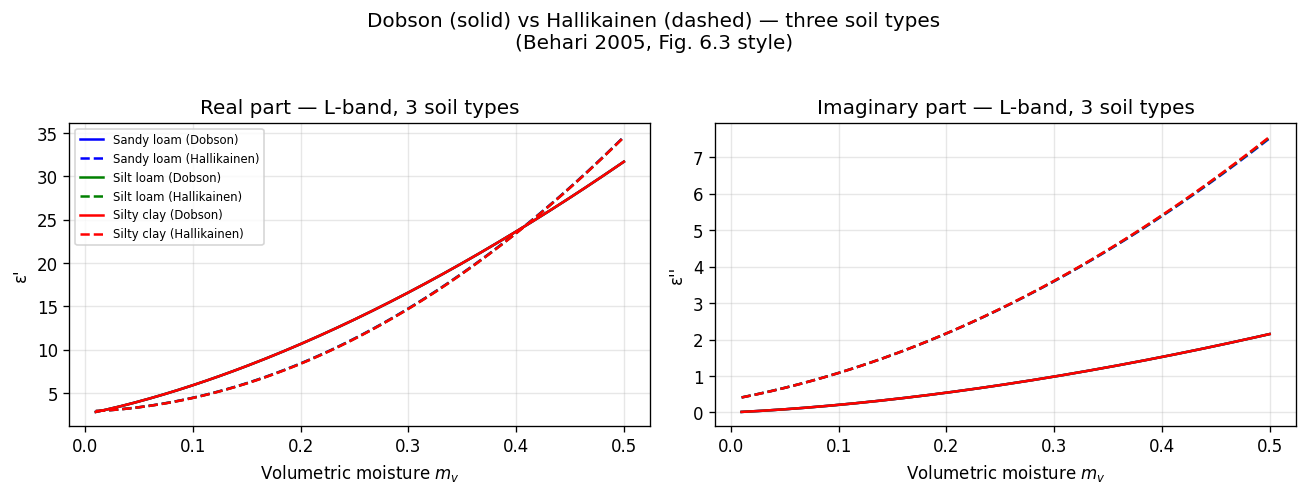

In [3]:
# Soil types from Behari Table 5.6 / Hallikainen 1985
soils = [
    ('Sandy loam',  51.5, 13.5),
    ('Silt loam',   17.2, 19.0),
    ('Silty clay',   5.0, 47.4),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['b', 'g', 'r']

for (name, sand, clay), col in zip(soils, colors):
    eps_db  = dobson_semiemp(mv, freq_ghz=1.4, sand_pct=sand, clay_pct=clay)
    eps_hal = hallikainen_dielectric(mv, freq_ghz=1.4, sand=sand/100, clay=clay/100)
    axes[0].plot(mv, eps_db.real,  color=col, ls='-',  label=f'{name} (Dobson)')
    axes[0].plot(mv, eps_hal.real, color=col, ls='--', label=f'{name} (Hallikainen)')
    axes[1].plot(mv, eps_db.imag,  color=col, ls='-')
    axes[1].plot(mv, eps_hal.imag, color=col, ls='--')

for ax, ylabel, title in zip(axes, ["ε'", "ε''"],
                              ['Real part', 'Imaginary part']):
    ax.set_xlabel('Volumetric moisture $m_v$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} — L-band, 3 soil types')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7)
plt.suptitle('Dobson (solid) vs Hallikainen (dashed) — three soil types\n'
             '(Behari 2005, Fig. 6.3 style)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_dobson_vs_hallikainen.png', dpi=150)
plt.show()

## Frequency dependence of mixing models (Fig. 5.11/5.12 style)

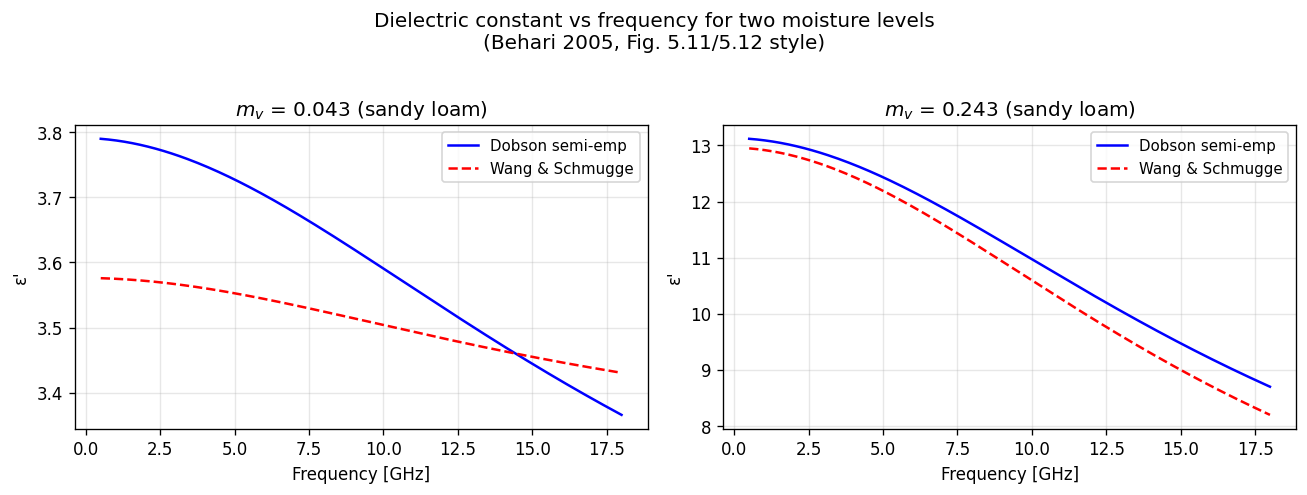

In [4]:
freq_range = np.linspace(0.5, 18, 200)
mv_vals = [0.043, 0.243]   # low and high moisture (Behari Fig. 5.11/5.12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for mv_val, ax in zip(mv_vals, axes):
    eps_db  = dobson_semiemp(np.full_like(freq_range, mv_val), freq_ghz=freq_range)
    eps_ws  = wang_schmugge(np.full_like(freq_range, mv_val), freq_ghz=freq_range)
    ax.plot(freq_range, eps_db.real, 'b-',  label='Dobson semi-emp')
    ax.plot(freq_range, eps_ws.real, 'r--', label='Wang & Schmugge')
    ax.set_xlabel('Frequency [GHz]')
    ax.set_ylabel("ε'")
    ax.set_title(f'$m_v$ = {mv_val:.3f} (sandy loam)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Dielectric constant vs frequency for two moisture levels\n'
             '(Behari 2005, Fig. 5.11/5.12 style)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_eps_vs_freq_moisture.png', dpi=150)
plt.show()

## Penetration depth vs moisture and frequency

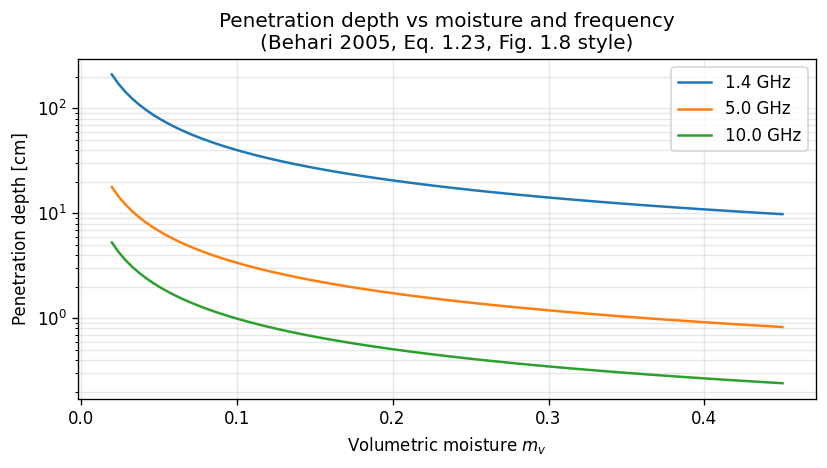

In [5]:
mv_pd = np.linspace(0.02, 0.45, 100)
freqs = [1.4, 5.0, 10.0]

fig, ax = plt.subplots(figsize=(7, 4))
for f in freqs:
    eps = dobson_semiemp(mv_pd, freq_ghz=f)
    Pd  = penetration_depth(eps, f)
    ax.semilogy(mv_pd, Pd * 100, label=f'{f} GHz')

ax.set_xlabel('Volumetric moisture $m_v$')
ax.set_ylabel('Penetration depth [cm]')
ax.set_title('Penetration depth vs moisture and frequency\n'
             '(Behari 2005, Eq. 1.23, Fig. 1.8 style)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('../examples/fig_penetration_depth.png', dpi=150)
plt.show()

## Emissivity and brightness temperature vs moisture

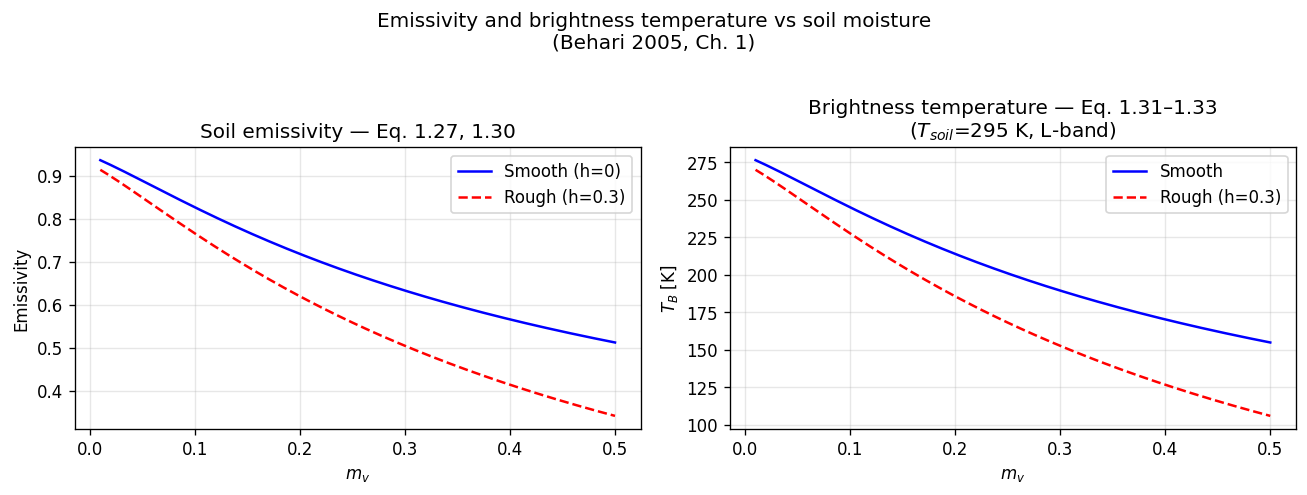

In [6]:
from navasar.behari import emissivity_smooth, emissivity_rough, brightness_temperature

eps_db = dobson_semiemp(mv, freq_ghz=1.4)
e_smooth = emissivity_smooth(eps_db.real)
e_rough  = emissivity_rough(eps_db.real, h_roughness=0.3)
TB_smooth = brightness_temperature(eps_db.real, T_soil_K=295)
TB_rough  = brightness_temperature(eps_db.real, T_soil_K=295, h_roughness=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mv, e_smooth, 'b-',  label='Smooth (h=0)')
axes[0].plot(mv, e_rough,  'r--', label='Rough (h=0.3)')
axes[0].set_xlabel('$m_v$'); axes[0].set_ylabel('Emissivity')
axes[0].set_title('Soil emissivity — Eq. 1.27, 1.30')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(mv, TB_smooth, 'b-',  label='Smooth')
axes[1].plot(mv, TB_rough,  'r--', label='Rough (h=0.3)')
axes[1].set_xlabel('$m_v$'); axes[1].set_ylabel('$T_B$ [K]')
axes[1].set_title('Brightness temperature — Eq. 1.31–1.33\n($T_{soil}$=295 K, L-band)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Emissivity and brightness temperature vs soil moisture\n'
             '(Behari 2005, Ch. 1)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_emissivity_brightness_T.png', dpi=150)
plt.show()